In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from keras.optimizers import Adam
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("combined_air_quality_modified.csv")
df = df.sort_values('date')
df.head()

,country,date,county,sitename,aqi,status,pm2.5,pm10,no,no2,nox,co,so2,o3,siteid
0,Philippines,2014-01-01,NCR,Manila,118.0,Unhealthy for Sensitive Groups,42.450712,105.388892,18.993939,68.680839,46.467632,1.180798,23.094493,12.319120,NaN
4176,Philippines,2014-01-01,Region II (Cagayan Valley),Cauayan,75.0,Moderate,23.586933,37.758559,18.139599,25.207036,22.973716,0.817300,7.100486,42.524681,NaN
9936,Philippines,2014-01-01,Region V (Bicol),Sorsogon City,63.0,Moderate,17.866673,37.519276,12.653516,18.765847,16.652262,0.892755,9.208096,40.003560,NaN
10080,Philippines,2014-01-01,Region V (Bicol),Masbate City,79.0,Moderate,25.350025,45.701587,9.424173,31.094817,21.475065,1.174867,14.641140,58.184813,NaN
4032,Philippines,2014-01-01,Region II (Cagayan Valley),Santiago,59.0,Moderate,15.811384,29.334256,9.228539,16.178484,13.465722,0.422890,5.918269,15.714872,NaN


In [3]:
features=['so2','co','o3','pm2.5','pm10','no2','nox','no']

status=['aqi']
X=df[features]
y=df[status]  


In [4]:
unique_dates = df['date'].unique()
split_idx = int(len(unique_dates) * 0.8)
train_dates = unique_dates[:split_idx]

df_train = df[df['date'].isin(train_dates)].copy()
df_test = df[~df['date'].isin(train_dates)].copy()

In [5]:
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

def create_sequences_by_station(dataframe, feature_cols, window_size=24):
    X_seq, y_seq = [], []
    # Group by station name to keep timelines fully isolated
    for station, group in dataframe.groupby('sitename'):
        group_sorted = group.sort_values('date')
        group_features = group_sorted[feature_cols].values
        group_targets = group_sorted['aqi'].values
        
        if len(group_sorted) > window_size:
            for i in range(len(group_sorted) - window_size):
                X_seq.append(group_features[i : (i + window_size)])
                y_seq.append(group_targets[i + window_size])
                
    return np.array(X_seq), np.array(y_seq)

# Build valid 3D shapes representing (Samples, 24 Hours, 8 Features)
X_train_seq, y_train_seq = create_sequences_by_station(df_train, features, window_size=24)
X_test_seq, y_test_seq = create_sequences_by_station(df_test, features, window_size=24)

print("Clean Train Sequence Shape:", X_train_seq.shape)
print("Clean Test Sequence Shape:", X_test_seq.shape)

Clean Train Sequence Shape: (112253, 24, 8)
Clean Test Sequence Shape: (24349, 24, 8)


In [6]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(24, 8)), 
    
    # First GRU layer 
    layers.GRU(256, return_sequences=True),
    layers.BatchNormalization(), 
    layers.Dropout(0.4),
    
    # First GRU layer 
    layers.GRU(128, return_sequences=True),
    layers.BatchNormalization(), 
    layers.Dropout(0.3),
    

    # Third GRU layer
    layers.GRU(64),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(1, activation='linear')
])

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mae',
    metrics=['mae','mse'

    ]
)

In [8]:
# callback for saving checkpoint and early stop
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='PhT_best_model_rf_regressor.keras', monitor='val_loss', save_best_only=True),
    reduce_lr
]

In [9]:
model.fit(
X_train_seq, y_train_seq,
epochs=100,
batch_size=256,
shuffle=True,
validation_split=0.2,
verbose=1,
callbacks=my_callbacks
)#training nn

Epoch 1/100


KeyboardInterrupt: 

In [11]:
best_model=tf.keras.models.load_model("PhT_best_model_rf_regressor.keras")
nn_pseudo_labels = best_model.predict(X_train_seq)
y_pseudo_train = nn_pseudo_labels.flatten()

#Flatten properly aligned 3D sequences into a 2D format for the Random Forest
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_flat_sequences = X_test_seq.reshape(X_test_seq.shape[0], -1)

#Train the student Regressor with proper initialization constraints
print("Training Optimized Student Random Forest...")
rf_distilled = RandomForestRegressor(
    n_estimators=100,       # Streamlines tree generation
    max_depth=12,          # Limits float split depth to run efficiently
    n_jobs=-1,             # Runs processing in parallel across all CPU cores
    random_state=42
)
rf_distilled.fit(X_train_flat, y_pseudo_train)

#Predict and evaluate performance metrics
y_pred_rf = rf_distilled.predict(X_test_flat_sequences)

print("\n--- Corrected Distilled Random Forest Regression Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_seq, y_pred_rf):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_seq, y_pred_rf):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_seq, y_pred_rf)):.4f}")
print(f"R-squared (R2) Variance Score: {r2_score(y_test_seq, y_pred_rf):.4f}")

3508/3508 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step
Training Optimized Student Random Forest...

--- Corrected Distilled Random Forest Regression Performance ---
Mean Absolute Error (MAE): 2.3909
Mean Squared Error (MSE): 16.7575
Root Mean Squared Error (RMSE): 4.0936
R-squared (R2) Variance Score: 0.9288


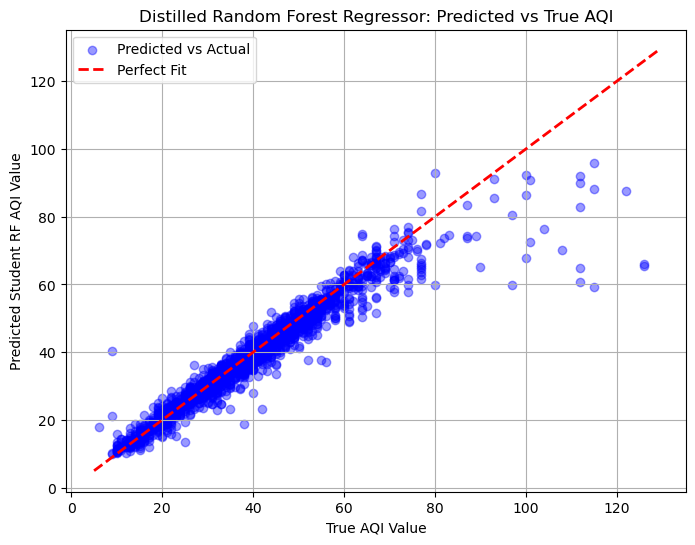

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_seq[:2000], y_pred_rf[:2000], alpha=0.4, color='b', label='Predicted vs Actual')

# Plot accurate perfect diagonal trendline boundary
perfect_line = [min(y_test_seq), max(y_test_seq)]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('True AQI Value')
plt.ylabel('Predicted Student RF AQI Value')
plt.title('Distilled Random Forest Regressor: Predicted vs True AQI')
plt.legend()
plt.grid(True)
plt.savefig('PhT_regression_fit_perf.png')

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# 1. Flatten the 3D sequence arrays into 2D matrices for Random Forest
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)

# 2. Define the parameter search space for the Random Forest Regressor
param_dist_rf_reg = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.3, 0.5], # Good range since we have 192 flattened columns
    'bootstrap': [True]
}

# 3. Initialize the baseline RandomForestRegressor
rf_reg_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# 4. Configure the Randomized Search
print("Starting Hyperparameter Tuning for Random Forest Regressor...")
rf_reg_search = RandomizedSearchCV(
    estimator=rf_reg_base,
    param_distributions=param_dist_rf_reg,
    n_iter=10, 
    cv=3, 
    scoring='neg_mean_absolute_error', # Optimizing to minimize MAE
    random_state=42,
    n_jobs=-1
)

# 5. Fit the search on the 2D flattened data and Teacher's continuous pseudo-labels
rf_reg_search.fit(X_train_flat, y_pseudo_train)

# 6. Extract and print the best model configuration
print("\n✅ Best Random Forest Regressor Parameters Found:")
print(rf_reg_search.best_params_)

best_rf_reg = rf_reg_search.best_estimator_

# 7. Generate predictions using the optimized regressor
y_pred_rf_reg = best_rf_reg.predict(X_test_flat)

# 8. Evaluate performance metrics
print("\n--- Tuned Distilled Random Forest Regressor Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_seq, y_pred_rf_reg):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_seq, y_pred_rf_reg):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_seq, y_pred_rf_reg)):.4f}")
print(f"R-squared (R2) Score: {r2_score(y_test_seq, y_pred_rf_reg):.4f}")


Starting Hyperparameter Tuning for Random Forest Regressor...

✅ Best Random Forest Regressor Parameters Found:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': 20, 'bootstrap': True}

--- Tuned Distilled Random Forest Regressor Performance ---
Mean Absolute Error (MAE): 2.0614
Mean Squared Error (MSE): 14.4369
Root Mean Squared Error (RMSE): 3.7996
R-squared (R2) Score: 0.9387
